# Healthcare Claims: Encounter-Level Cost Analysis

**Dataset:** `HealthcareDataset_PublicRelease.csv` — hospital claim line items, calendar year 2020.

**Contents**

1. Data description
2. Aggregation of claims per medical encounter; statistical description of relevant factors
3. Multivariable linear model for encounter cost: fit, t-tests, F-test, coefficient interpretation


## 1. Data description

Each row is a **claim line item**: a single billed service (drug, lab test, room charge, ...) within a hospital claim. Key columns:

| Column | Meaning |
|---|---|
| `MedicalClaim` | Claim identifier — one claim = one **medical encounter** (hospital visit) |
| `ClaimItem`, `Id` | Line-item identifiers within a claim |
| `MemberID`, `MemberName`, `BirthDate`, `County` | Anonymized patient info |
| `HospitalName`, `HospitalType` | Facility (148 hospitals; mostly acute-care) |
| `StartDate`, `EndDate` | Service dates for the line item |
| `PrincipalDiagnosis(Desc)` | ICD-10 principal diagnosis of the claim |
| `RevenueCode(Desc)` | Billing category of the service |
| `TypeFlag` | `ER` (emergency) or `INP` (inpatient) |
| `TotalExpenses` | Cost of the line item ($) |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

df = pd.read_csv("https://github.com/thousandoaks/Python4DS-I/raw/main/datasets/HealthcareDataset_PublicRelease.csv",sep=',',parse_dates=['StartDate','EndDate','BirthDate'])
     
print(f'Rows (claim line items): {len(df):,}')
print(f'Columns: {df.shape[1]}')
df.head()

Rows (claim line items): 52,563
Columns: 17


,Id,MemberName,MemberID,County,MedicalClaim,ClaimItem,HospitalName,HospitalType,StartDate,EndDate,PrincipalDiagnosisDesc,PrincipalDiagnosis,RevenueCodeDesc,RevenueCode,TypeFlag,BirthDate,TotalExpenses
0,634363,e659f3f4,6a380a28,6f943458,c1e3436737c77899,18,04b77561,HOSPITAL,2020-01-08,2020-01-08,Epigastric pain,R10.13,DRUGS REQUIRE SPECIFIC ID: DRUGS REQUIRING DET...,636.00,ER,1967-05-13,15.15
1,634364,e659f3f4,6a380a28,6f943458,c1e3436737c77899,21,04b77561,HOSPITAL,2020-01-08,2020-01-08,Epigastric pain,R10.13,DRUGS REQUIRE SPECIFIC ID: DRUGS REQUIRING DET...,636.00,ER,1967-05-13,3.07
2,634387,e659f3f4,6a380a28,6f943458,c1e3436737c77899,10,04b77561,HOSPITAL,2020-01-08,2020-01-08,Epigastric pain,R10.13,LABORATORY - CLINICAL DIAGNOSTIC: HEMATOLOGY,305.00,ER,1967-05-13,123.90
3,634388,e659f3f4,6a380a28,6f943458,c1e3436737c77899,20,04b77561,HOSPITAL,2020-01-08,2020-01-08,Epigastric pain,R10.13,DRUGS REQUIRE SPECIFIC ID: DRUGS REQUIRING DET...,636.00,ER,1967-05-13,7.51
4,634389,e659f3f4,6a380a28,6f943458,c1e3436737c77899,19,04b77561,HOSPITAL,2020-01-08,2020-01-08,Epigastric pain,R10.13,DRUGS REQUIRE SPECIFIC ID: DRUGS REQUIRING DET...,636.00,ER,1967-05-13,8.63


In [2]:
# Structure, missing values, cardinality
summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'unique': df.nunique()
})
summary

,dtype,missing,unique
Id,int64,0,52563
MemberName,object,0,1753
MemberID,object,0,1757
County,object,0,19
MedicalClaim,object,0,3361
ClaimItem,int64,0,127
HospitalName,object,0,148
HospitalType,object,0,3
StartDate,datetime64[ns],0,366
EndDate,datetime64[ns],0,366


In [3]:
print(f"Encounters (claims):  {df.MedicalClaim.nunique():,}")
print(f"Patients (members):   {df.MemberID.nunique():,}")
print(f"Hospitals:            {df.HospitalName.nunique()}")
print(f"Date range:           {df.StartDate.min().date()} to {df.StartDate.max().date()}")
print()
print("Claim type (line items):")
print(df.TypeFlag.value_counts().to_string())
print()
print("Line-item cost ($):")
print(df.TotalExpenses.describe().to_string())

Encounters (claims):  3,361
Patients (members):   1,757
Hospitals:            148
Date range:           2020-01-01 to 2020-12-31

Claim type (line items):
TypeFlag
INP    28585
ER     23978

Line-item cost ($):
count    52,563.00
mean      2,735.23
std       8,292.18
min           0.00
25%         194.64
50%         675.26
75%       2,309.27
max     504,533.40


**Summary.** 52,563 line items belonging to 3,361 encounters for 1,757 patients across 148 hospitals during 2020. The data are essentially clean (2 missing `RevenueCodeDesc` values only). Line-item costs are strongly right-skewed (median ≈ \$675, mean ≈ \$2,735). Since costs are billed per line item, the natural unit of analysis for *cost of care* is the **encounter**, which we build next.

## 2. Aggregation of claims per medical encounter

We aggregate line items by `MedicalClaim`. (Each claim maps to exactly one patient and one claim type, so `first` is safe for patient-level fields.) Derived encounter-level variables — all **quantitative**:

* **`TotalCost`** — sum of `TotalExpenses` over the encounter (**response**)
* **`NumLineItems`** — number of billed line items (volume of services)
* **`NumRevenueCodes`** — number of *distinct* revenue codes (breadth/complexity of care)
* **`LengthOfStay`** — days from earliest `StartDate` to latest `EndDate`
* **`Age`** — patient age in years at the start of the encounter


In [4]:
enc = (df.groupby('MedicalClaim')
         .agg(TotalCost=('TotalExpenses', 'sum'),
              NumLineItems=('Id', 'count'),
              NumRevenueCodes=('RevenueCode', 'nunique'),
              StartDate=('StartDate', 'min'),
              EndDate=('EndDate', 'max'),
              BirthDate=('BirthDate', 'first'),
              TypeFlag=('TypeFlag', 'first'),
              Diagnosis=('PrincipalDiagnosisDesc', 'first'))
         .reset_index())

enc['LengthOfStay'] = (enc.EndDate - enc.StartDate).dt.days
enc['Age'] = (enc.StartDate - enc.BirthDate).dt.days / 365.25

factors = ['TotalCost', 'NumLineItems', 'NumRevenueCodes', 'LengthOfStay', 'Age']
print(f'Encounters: {len(enc):,}')
enc[factors + ['TypeFlag', 'Diagnosis']].head()

Encounters: 3,361


,TotalCost,NumLineItems,NumRevenueCodes,LengthOfStay,Age,TypeFlag,Diagnosis
0,"4,668.69",4,4,0,64.23,ER,Strain of right Achilles
1,"53,501.26",24,24,6,74.86,INP,Trigeminal neuralgia
2,"17,115.71",18,13,0,64.38,ER,Acute bronchitis unspecif
3,"3,672.36",9,6,0,68.94,ER,Zoster without complicati
4,"2,548.70",3,3,0,73.34,ER,Pain in left foot


In [5]:
# Statistical description of the relevant factors
enc[factors].describe().T

,count,mean,std,min,25%,50%,75%,max
TotalCost,"3,361.00","42,776.53","69,406.60",156.10,"6,211.94","20,313.55","51,498.29","1,066,309.68"
NumLineItems,"3,361.00",15.64,10.77,1.00,8.00,15.00,21.00,127.00
NumRevenueCodes,"3,361.00",12.35,7.90,1.00,6.00,11.00,18.00,43.00
LengthOfStay,"3,361.00",2.61,4.82,0.00,0.00,1.00,4.00,129.00
Age,"3,361.00",71.07,12.85,20.51,65.76,72.62,79.71,99.71


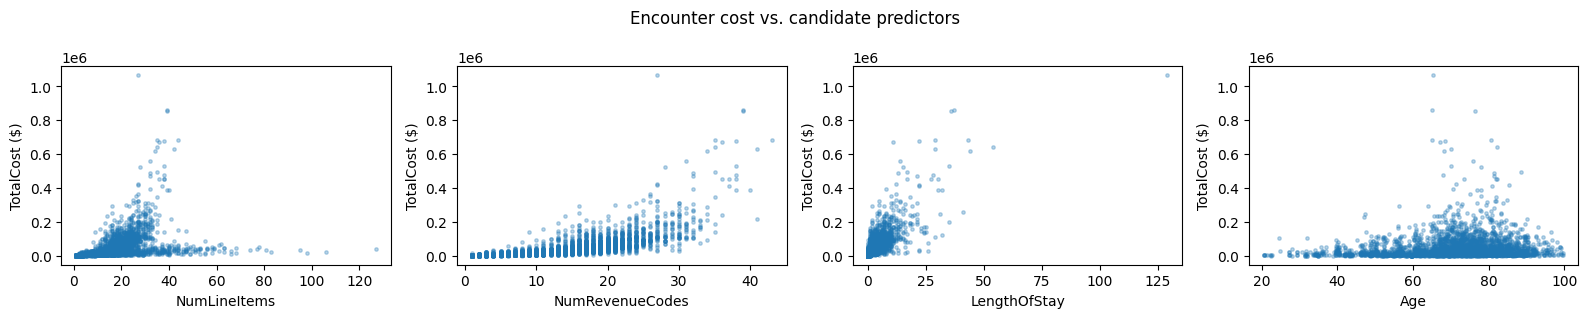

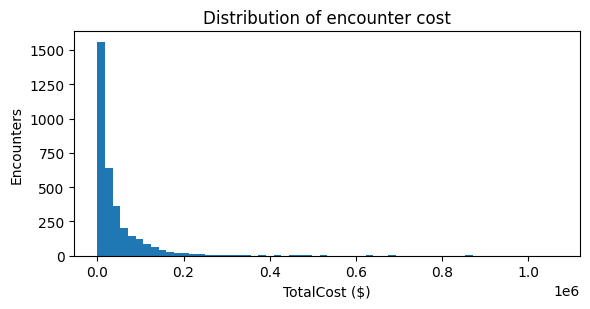

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
for ax, col in zip(axes, factors[1:]):
    ax.scatter(enc[col], enc.TotalCost, s=6, alpha=0.3)
    ax.set_xlabel(col); ax.set_ylabel('TotalCost ($)')
fig.suptitle('Encounter cost vs. candidate predictors')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.hist(enc.TotalCost, bins=60)
ax.set_xlabel('TotalCost ($)'); ax.set_ylabel('Encounters')
ax.set_title('Distribution of encounter cost')
plt.tight_layout(); plt.show()

In [7]:
# Correlation matrix
enc[factors].corr().round(3)

,TotalCost,NumLineItems,NumRevenueCodes,LengthOfStay,Age
TotalCost,1.00,0.43,0.70,0.79,0.10
NumLineItems,0.43,1.00,0.72,0.38,0.12
NumRevenueCodes,0.70,0.72,1.00,0.64,0.18
LengthOfStay,0.79,0.38,0.64,1.00,0.11
Age,0.10,0.12,0.18,0.11,1.00


**Description of the factors.** The typical encounter costs ≈ \$20k (median) with a heavy right tail (max > \$1M) — mean \$42.8k far exceeds the median. A typical encounter has ~15 line items spanning ~11 distinct revenue codes, lasts a median of 1 day (75% ≤ 4 days; many same-day ER visits have `LengthOfStay = 0`), and the patient population is elderly (median age ≈ 73).

The correlations suggest `LengthOfStay` (r ≈ 0.79) and `NumRevenueCodes` (r ≈ 0.70) are the strongest linear predictors of cost; `NumLineItems` is moderate (r ≈ 0.43) and `Age` weak (r ≈ 0.10). Note also that `NumLineItems` and `NumRevenueCodes` are themselves correlated (r ≈ 0.72) — relevant when interpreting the coefficients below.

## 3. Multivariable linear model

We regress encounter cost on four quantitative predictors (no transforms, no polynomial terms):

$$\text{TotalCost}_i = \beta_0 + \beta_1\,\text{NumLineItems}_i + \beta_2\,\text{LengthOfStay}_i + \beta_3\,\text{Age}_i + \beta_4\,\text{NumRevenueCodes}_i + \varepsilon_i,\qquad \varepsilon_i \sim N(0,\sigma^2)$$


In [8]:
y = enc['TotalCost']
X = sm.add_constant(enc[['NumLineItems', 'LengthOfStay', 'Age', 'NumRevenueCodes']])

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              TotalCost   R-squared:                       0.683
Model:                            OLS   Adj. R-squared:                  0.682
Method:                 Least Squares   F-statistic:                     1806.
Date:                Fri, 07 Aug 2026   Prob (F-statistic):               0.00
Time:                        12:50:28   Log-Likelihood:                -40306.
No. Observations:                3361   AIC:                         8.062e+04
Df Residuals:                    3356   BIC:                         8.065e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const           -5563.7167   3844.526     

### t-tests on individual coefficients

For each coefficient we test $H_0\!: \beta_j = 0$ versus $H_1\!: \beta_j \neq 0$ (holding the other predictors fixed), using $t = \hat\beta_j / \mathrm{se}(\hat\beta_j)$ with $n - p - 1 = 3356$ degrees of freedom.

In [9]:
ttests = pd.DataFrame({
    'coef': model.params,
    'std err': model.bse,
    't': model.tvalues,
    'p-value': model.pvalues,
    'CI 2.5%': model.conf_int()[0],
    'CI 97.5%': model.conf_int()[1],
})
ttests.round(4)

,coef,std err,t,p-value,CI 2.5%,CI 97.5%
const,"-5,563.72","3,844.53",-1.45,0.15,"-13,101.57","1,974.13"
NumLineItems,-355.45,91.86,-3.87,0.00,-535.57,-175.34
LengthOfStay,"8,152.19",184.54,44.17,0.00,"7,790.36","8,514.02"
Age,-117.97,53.36,-2.21,0.03,-222.59,-13.35
NumRevenueCodes,"3,323.00",151.82,21.89,0.00,"3,025.34","3,620.67"


**Interpretation of the t-tests / p-values.** The p-value is the probability, *if the predictor truly had no effect* ($\beta_j = 0$), of observing a t-statistic at least this extreme. At significance level $\alpha = 0.05$:

* **`LengthOfStay`** ($t \approx 44$, $p < 10^{-300}$) and **`NumRevenueCodes`** ($t \approx 22$, $p \approx 10^{-99}$): overwhelming evidence against $H_0$ — both contribute strongly to explaining cost even after controlling for the other predictors.
* **`NumLineItems`** ($t \approx -3.9$, $p \approx 0.0001$): significant, but *negative* — see interpretation below.
* **`Age`** ($t \approx -2.2$, $p \approx 0.027$): significant at the 5% level, though marginal — the evidence is far weaker than for the two main predictors, and its contribution is small.
* **Intercept** ($p \approx 0.15$): not significantly different from zero; this is unimportant, as the intercept is an extrapolation to an impossible encounter (0 line items, age 0).

We reject $H_0$ for all four predictors at the 5% level.

### F-test for overall significance

$H_0\!: \beta_1 = \beta_2 = \beta_3 = \beta_4 = 0$ (the model has no explanatory power) versus $H_1$: at least one $\beta_j \neq 0$.

In [10]:
import scipy.stats as st
print(f'F-statistic = {model.fvalue:,.1f}  on ({int(model.df_model)}, {int(model.df_resid)}) df')
print(f'p-value     = {model.f_pvalue:.3g}')
print(f'F critical value (alpha = 0.05) = {st.f.ppf(0.95, model.df_model, model.df_resid):.2f}')
print(f'R-squared          = {model.rsquared:.3f}')
print(f'Adjusted R-squared = {model.rsquared_adj:.3f}')

F-statistic = 1,806.3  on (4, 3356) df
p-value     = 0
F critical value (alpha = 0.05) = 2.37
R-squared          = 0.683
Adjusted R-squared = 0.682


**Interpretation of the F-test.** $F \approx 1806$ dwarfs the 5% critical value ($\approx 2.37$), so $p \approx 0$: we decisively reject $H_0$. The regression as a whole is highly significant — the four predictors jointly explain **$R^2 \approx 68\%$** of the variance in encounter cost (adjusted $R^2 \approx 0.682$, essentially identical since $n \gg p$).

### Interpretation of the coefficients

Each coefficient is the expected change in encounter cost for a **one-unit increase in that predictor, holding the other three fixed**:

* **`LengthOfStay` ≈ +\$8,150 per day.** The dominant cost driver: each additional day in hospital adds about \$8.2k (95% CI ≈ [\$7.8k, \$8.5k]), holding service volume, breadth, and age fixed.
* **`NumRevenueCodes` ≈ +\$3,320 per distinct revenue code.** Each additional *type* of billed service (a proxy for clinical complexity — imaging + surgery + ICU, etc.) adds about \$3.3k.
* **`NumLineItems` ≈ −\$355 per line item.** Counter-intuitive sign: marginally (r = +0.43) more line items means higher cost, but *conditional on* length of stay and number of distinct revenue codes, extra line items indicate many small repeated charges (e.g. cheap drug administrations) rather than expensive services. This sign flip is a classic consequence of the collinearity with `NumRevenueCodes` (r ≈ 0.72) — a caution against reading multiple-regression coefficients as marginal effects.
* **`Age` ≈ −\$118 per year.** A small negative adjustment: conditional on utilization (stay length, service volume/breadth), older patients cost slightly less per encounter. Age's raw correlation with cost is weak (r ≈ 0.10); most of any age effect operates *through* utilization, not on top of it.
* **Intercept ≈ −\$5,565**: not significant and not meaningful on its own (no encounter has zero line items).

**Caveats.** The response is heavily right-skewed and the residual diagnostics (Jarque–Bera, kurtosis ≈ 38) show clearly non-normal, heteroskedastic errors, so the model is best read as a description of average cost structure; p-values here are robust mainly because $n$ is large. A log-cost specification would fit the distributional assumptions better but is outside the scope of this exercise (untransformed quantitative predictors only).

## 4. Reduced model

`Age` and `NumLineItems` contribute almost nothing (adjusted $R^2$ falls only from 0.6825 to 0.6808 without them), so we drop both and keep the two strong predictors:

$$\text{TotalCost}_i = \beta_0 + \beta_1\,\text{LengthOfStay}_i + \beta_2\,\text{NumRevenueCodes}_i + \varepsilon_i$$

In [11]:
Xr = sm.add_constant(enc[['LengthOfStay', 'NumRevenueCodes']])
reduced = sm.OLS(enc.TotalCost, Xr).fit()

res = pd.concat([reduced.params, reduced.bse, reduced.tvalues,
                 reduced.pvalues, reduced.conf_int()], axis=1)
res.columns = ['coef', 'std err', 't', 'p-value', 'CI 2.5%', 'CI 97.5%']
print(f'R-squared          = {reduced.rsquared:.3f}')
print(f'Adjusted R-squared = {reduced.rsquared_adj:.3f}')
print(f'F = {reduced.fvalue:,.0f}   (p = {reduced.f_pvalue:.3g})')
res.round(2)

R-squared          = 0.681
Adjusted R-squared = 0.681
F = 3,584   (p = 0)


,coef,std err,t,p-value,CI 2.5%,CI 97.5%
const,"-14,507.85","1,318.96",-11.00,0.00,"-17,093.89","-11,921.81"
LengthOfStay,"8,266.96",182.73,45.24,0.00,"7,908.69","8,625.23"
NumRevenueCodes,"2,893.87",111.53,25.95,0.00,"2,675.20","3,112.54"


**Interpretation.** The reduced model still explains **$R^2 \approx 0.68$** of the variance in encounter cost — essentially identical to the four-predictor model.

* **`LengthOfStay`: +\$8,267 per day** ($t = 45.2$, $p < 10^{-300}$; 95% CI [\$7,909, \$8,625]). Each additional day in hospital adds about \$8.3k to expected cost, holding service breadth fixed. The narrow CI (±\$360) makes this a very precisely estimated effect.
* **`NumRevenueCodes`: +\$2,894 per distinct service category** ($t = 25.9$, $p \approx 10^{-134}$; 95% CI [\$2,675, \$3,113]). Each additional *type* of billed service adds about \$2.9k, holding length of stay fixed.
* **Intercept: −\$14,508** (95% CI [−\$17,094, −\$11,922]). Statistically significant but not meaningful by itself — no encounter has 0 revenue codes; it simply anchors the plane.

Both p-values are vanishingly small: the data are entirely incompatible with either predictor having no effect. Since neither CI comes anywhere near 0, the conclusions are unambiguous.

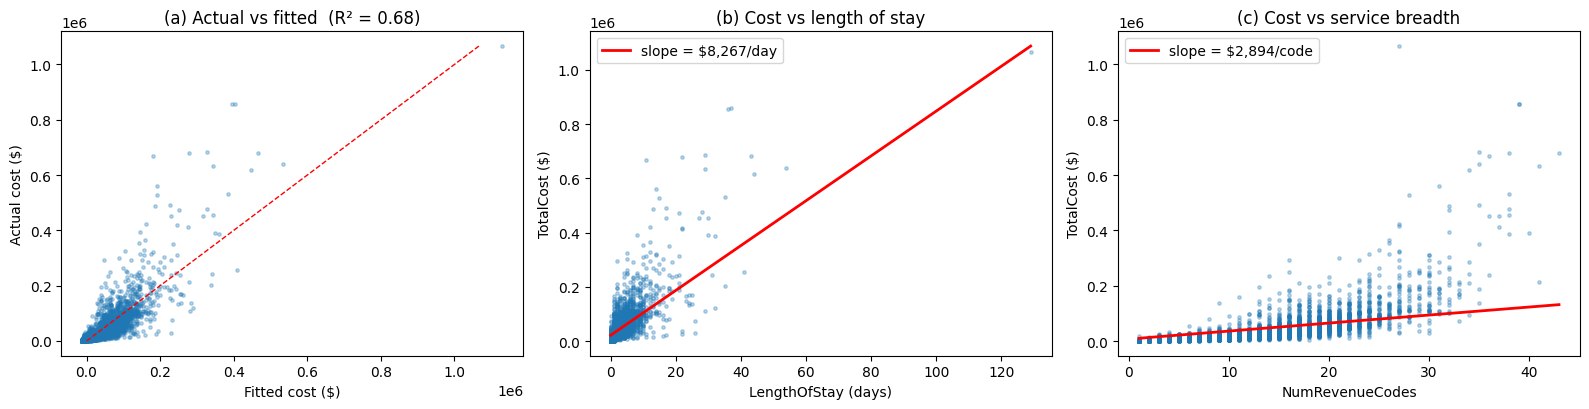

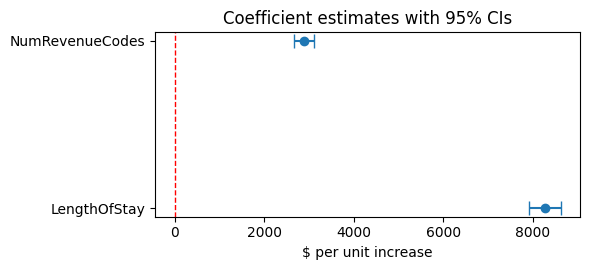

In [12]:
fitted = reduced.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# (a) actual vs fitted
ax = axes[0]
ax.scatter(fitted, enc.TotalCost, s=6, alpha=0.3)
lim = [0, enc.TotalCost.max()]
ax.plot(lim, lim, 'r--', lw=1)
ax.set_xlabel('Fitted cost ($)'); ax.set_ylabel('Actual cost ($)')
ax.set_title(f'(a) Actual vs fitted  (R² = {reduced.rsquared:.2f})')

# (b) cost vs LengthOfStay with model line (NumRevenueCodes at its mean)
ax = axes[1]
ax.scatter(enc.LengthOfStay, enc.TotalCost, s=6, alpha=0.3)
xs = np.linspace(0, enc.LengthOfStay.max(), 100)
b = reduced.params
ax.plot(xs, b['const'] + b['LengthOfStay']*xs
            + b['NumRevenueCodes']*enc.NumRevenueCodes.mean(), 'r-', lw=2,
        label=f"slope = ${b['LengthOfStay']:,.0f}/day")
ax.set_xlabel('LengthOfStay (days)'); ax.set_ylabel('TotalCost ($)')
ax.set_title('(b) Cost vs length of stay'); ax.legend()

# (c) cost vs NumRevenueCodes with model line (LengthOfStay at its mean)
ax = axes[2]
ax.scatter(enc.NumRevenueCodes, enc.TotalCost, s=6, alpha=0.3)
xs = np.linspace(1, enc.NumRevenueCodes.max(), 100)
ax.plot(xs, b['const'] + b['NumRevenueCodes']*xs
            + b['LengthOfStay']*enc.LengthOfStay.mean(), 'r-', lw=2,
        label=f"slope = ${b['NumRevenueCodes']:,.0f}/code")
ax.set_xlabel('NumRevenueCodes'); ax.set_ylabel('TotalCost ($)')
ax.set_title('(c) Cost vs service breadth'); ax.legend()

plt.tight_layout(); plt.show()

# coefficient estimates with 95% CIs
fig, ax = plt.subplots(figsize=(6, 2.8))
ci = reduced.conf_int().drop('const'); est = reduced.params.drop('const')
ax.errorbar(est, range(len(est)),
            xerr=(est - ci[0], ci[1] - est),
            fmt='o', capsize=5, color='tab:blue')
ax.axvline(0, color='r', ls='--', lw=1)
ax.set_yticks(range(len(est))); ax.set_yticklabels(est.index)
ax.set_xlabel('$ per unit increase')
ax.set_title('Coefficient estimates with 95% CIs')
plt.tight_layout(); plt.show()

**What the plots show.** (a) Fitted values track actual costs along the 45° line, with scatter widening for expensive encounters (the familiar heteroskedasticity). (b, c) Both predictors have clear positive linear relationships with cost, and the model lines match the point clouds well. The CI plot confirms both effects are far from zero, with length of stay the dominant driver.

**Conclusion:** encounter cost is well summarized by two numbers — how long the patient stayed and how many kinds of service they received — at ≈ \$8.3k/day and ≈ \$2.9k/service category, together explaining about two-thirds of cost variance.